# Laboratorio 3: Modelos de Regresión Lineal
## Consultoría para SmartStay Advisors

En esta primera fase de la consultoría, se realiza un análisis exploratorio detallado del conjunto de datos proporcionado. El objetivo principal es predecir el precio de las propiedades, por lo que nos enfocaremos en entender la distribución de los datos, realizar agrupamiento y evaluar la relación de las variables independientes con nuestra variable respuesta.

In [ ]:
# Instalar librerias necesarias

%pip install pandas numpy matplotlib seaborn pyreadr scikit-learn scipy

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from sklearn.cluster import KMeans
import scipy.stats as stats

# Configuración para las gráficas
sns.set_theme(style="whitegrid")

# Cargamos el conjunto de datos original
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Verificamos las dimensiones iniciales
print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset contiene 171748 filas y 80 columnas.


## 1. Descripción de las Variables Seleccionadas
Dado que el dataset original cuenta con 80 columnas, hemos seleccionado las más relevantes para nuestro objetivo de predecir el precio y la ocupación. Las variables se agrupan de la siguiente manera:

**Variable Respuesta**

- price: Es el precio por noche de la propiedad. Viene en formato de texto con símbolos de moneda, por lo que requerirá limpieza para usarla en los modelos.

**Variables de la Propiedad**

- property_type y room_type: Categorizan el tipo de inmueble y el nivel de privacidad (ej. casa entera, habitación privada).

- accommodates: Capacidad máxima de huéspedes.

- bedrooms y beds: Cantidad de habitaciones y camas.

- bathrooms / bathrooms_text: Cantidad de baños disponibles.

**Variables de Ubicación**

- city y neighbourhood: Nos indican la ubicación textual de la propiedad.

- latitude y longitude: Coordenadas exactas de la propiedad. Se dan en grados.

**Variables de Reputación y Desempeño**

- number_of_reviews: Total de evaluaciones recibidas.

- review_scores_rating: Calificación promedio de los huéspedes.

- availability_365: Días disponibles en el año.

In [14]:
# Verificamos si los datos son solo de una ciudad o de varias
ciudades_unicas = df['city'].value_counts()
print("Distribución de propiedades por ciudad:")
print(ciudades_unicas.head(10)) 
# Mostramos el top 10

Distribución de propiedades por ciudad:
city
Los Angeles, California      45585
New York, New York           36261
Hawaii                       33457
San Diego, California        13162
Austin, Texas                10533
Chicago, Illinois             8660
San Francisco, California     7535
Washington, D.C.              6374
Rhode Island                  5762
Boston, Massachusetts         4419
Name: count, dtype: int64


## 2. Preprocesamiento y Limpieza
Como se notó en la exploración inicial, la columna "price" necesita limpieza ya que viene como texto, incluyendo signos de dólar y comas. Además, debemos descartar los registros que no tengan un precio definido, ya que no nos servirán para entrenar nuestro modelo.

In [15]:
# Limpieza price (quita $ y comas, y que sea numeric)
df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_clean = df.dropna(subset=['price']).copy()

# Eliminamos valores nulos en la variable respuesta
df_clean = df.dropna(subset=['price']).copy()

print(f"Tras limpiar los precios nulos, nos quedamos con {df_clean.shape[0]} registros útiles.")

Tras limpiar los precios nulos, nos quedamos con 76246 registros útiles.


## 3. Análisis Exploratorio de Datos
Exploraremos cómo se distribuyen los precios y cómo interactúan algunas características físicas de la propiedad con el costo por noche.

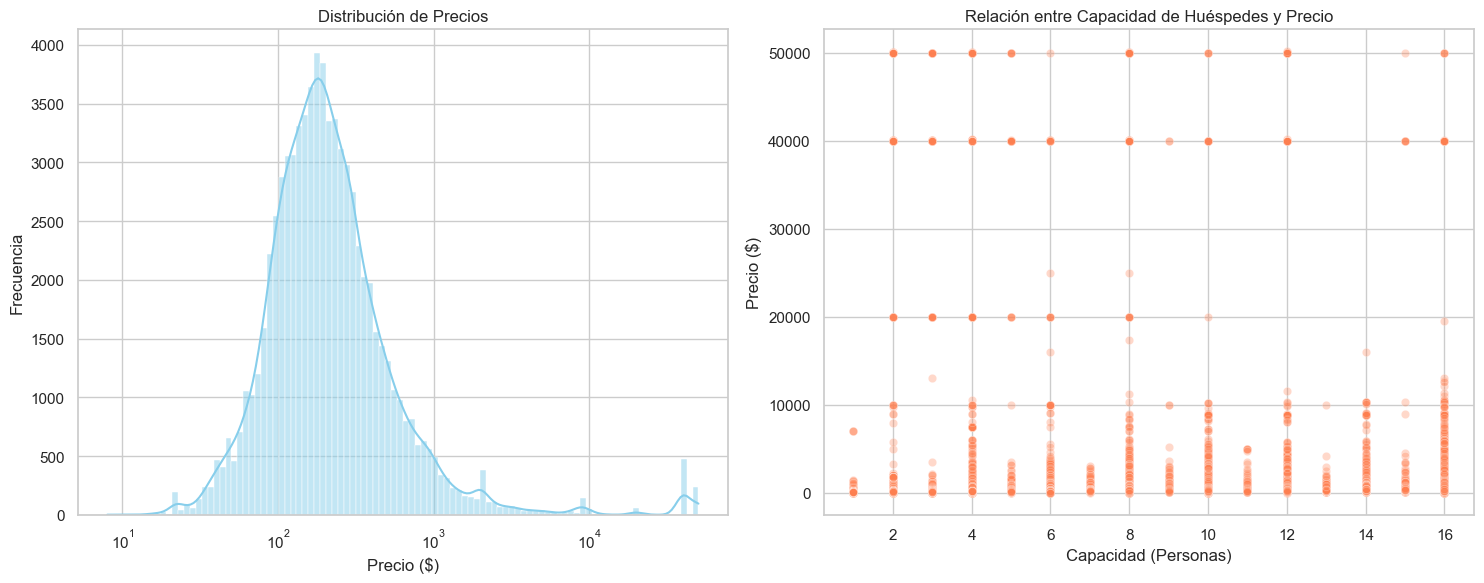

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribución del precio (escala logaritmica)
sns.histplot(df_clean['price'], bins=100, kde=True, ax=axes[0], color='skyblue', log_scale=True)
axes[0].set_title('Distribución de Precios')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Precio según capacidad
sns.scatterplot(x='accommodates', y='price', data=df_clean, alpha=0.3, ax=axes[1], color='coral')
axes[1].set_title('Relación entre Capacidad de Huéspedes y Precio')
axes[1].set_xlabel('Capacidad (Personas)')
axes[1].set_ylabel('Precio ($)')

plt.tight_layout()
plt.show()

### Hallazgos:
- Al observar la distribución de precios (graficada con una escala logarítmica en el eje X para no perder visibilidad), la curva adopta una forma de campana. Esto nos permite comprobar que la gran mayoría de las propiedades tienen sus precios alrededor de los 100 dólares ($10^2$). Sin embargo, la presencia de pequeños picos en el extremo derecho confirma que hay valores atípicos extremos que llegan hasta los $50,000. El hecho de que la gráfica adopte una distribución normal al usar una escala logarítmica es una prueba de que para cumplir los supuestos de una regresión lineal, será necesario aplicar una transformación a esta variable.

- La gráfica de dispersión nos dice una tendencia: a mayor capacidad de huéspedes, el límite superior del precio aumenta. Sin embargo, la varianza es muy alta. Existen propiedades para pocas personas que son muy costosas, lo que indica que otras variables (como la ubicación o el lujo) también son importantes.

## 4. Clustering
Aplicamos un algoritmo de K-Means utilizando las coordenadas geográficas (latitud y longitud). Esto nos permite agrupar las propiedades en "zonas" y evaluar si el precio varía dependiendo de la zona a la que pertenecen.

Usando 4 clusters (muestras: 76246)


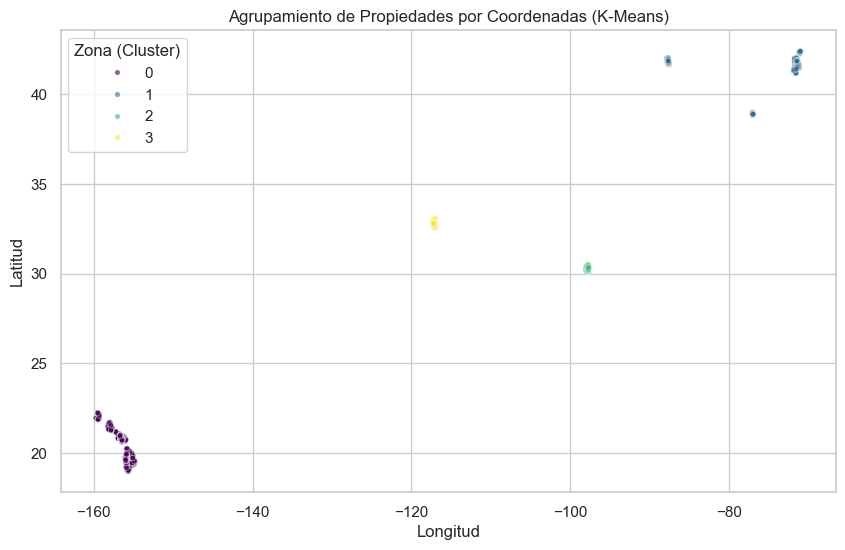

Precio Promedio por Zona Geográfica:
   zona_cluster   price
0             0  945.49
1             1  666.27
3             3  650.38
2             2  414.54


In [17]:
# Preparar geo_data
geo_data = df_clean.dropna(subset=['latitude', 'longitude']).copy()
geo_data['latitude']  = pd.to_numeric(geo_data['latitude'],  errors='coerce')
geo_data['longitude'] = pd.to_numeric(geo_data['longitude'], errors='coerce')
geo_data = geo_data.dropna(subset=['latitude', 'longitude'])
geo_data = geo_data[geo_data['latitude'].between(-90, 90) & geo_data['longitude'].between(-180, 180)]

# Ejecutar KMeans
n_clusters = min(4, len(geo_data))
print(f"Usando {n_clusters} clusters (muestras: {len(geo_data)})")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
geo_data.loc[:, 'zona_cluster'] = kmeans.fit_predict(geo_data[['latitude', 'longitude']])

# Visualizar
plt.figure(figsize=(10, 6))
sns.scatterplot(x='longitude', y='latitude', hue='zona_cluster', palette='viridis', data=geo_data, s=15, alpha=0.6)
plt.title('Agrupamiento de Propiedades por Coordenadas (K-Means)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Zona (Cluster)')
plt.show()

# Precio promedio por cluster
precio_zona = geo_data.groupby('zona_cluster')['price'].mean().round(2).reset_index().sort_values('price', ascending=False)
print("Precio Promedio por Zona Geográfica:")
print(precio_zona)

### Explicación del Clustering

Se utilizaron 4 clústeres geográficos. El gráfico de dispersión con longitudes entre -160 y -80 muestra que el algoritmo no separó una sola ciudad, sino que agrupa múltiples regiones a lo largo de Estados Unidos (desde Hawaii hasta lugares de la costa como Nueva York). Al revisar la tabla de precios promedio por clúster, confirmamos que la ubicación sí tiene un impacto económico. Existen zonas específicas, como el clúster 0 con un promedio de $945.49, donde el costo es bastante superior al resto. Esto sugiere que la pertenencia a una de estas regiones geográficas será una variable categórica clave para nuestro modelo.

## 5. Análisis de Relaciones con la Variable Respuesta y Normalidad

Se realizan pruebas estadísticas para evaluar la normalidad de nuestra variable respuesta y entender la fuerza de la correlación lineal entre los demás atributos numéricos y el precio.

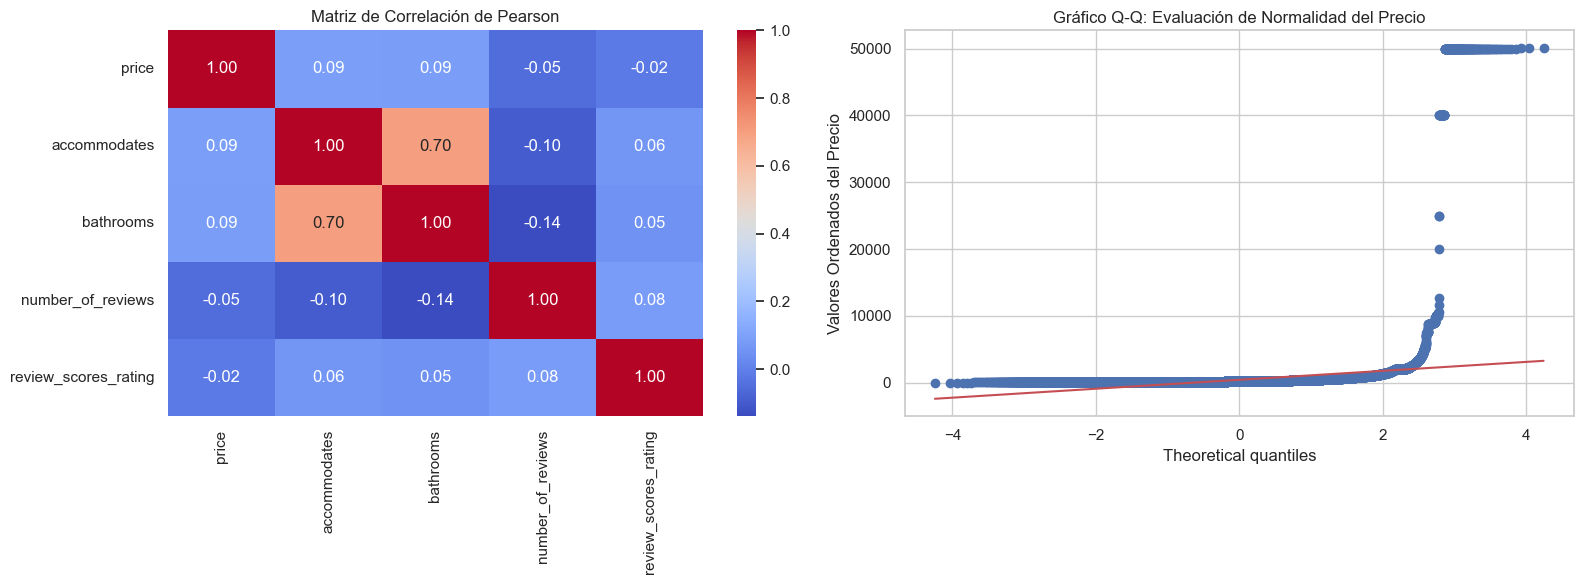

In [18]:
# Seleccionamos variables numéricas que nos parecen correctas
cols_num = ['price', 'accommodates', 'bathrooms', 'number_of_reviews', 'review_scores_rating']

# Nos aseguramos de tener las columnas listas (a veces viene como float, a veces nula)
df_corr = df_clean[cols_num].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Matriz de Correlación
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Matriz de Correlación de Pearson')

# 2. Prueba de Normalidad (Gráfico Q-Q)
stats.probplot(df_corr['price'], dist="norm", plot=axes[1])
axes[1].set_title('Gráfico Q-Q: Evaluación de Normalidad del Precio')
axes[1].set_ylabel('Valores Ordenados del Precio')

plt.tight_layout()
plt.show()

### Hallazgos del análisis de relaciones: 

Al analizar la matriz de correlación de Pearson, se obtiene que ninguna de las variables presenta un impacto lineal fuerte con el precio. Las correlaciones de la capacidad de huéspedes (accommodates) y la cantidad de baños (bathrooms) con el precio arrojan valores cercanos a cero. De igual forma, la reputación (review_scores_rating) y la cantidad de reseñas (number_of_reviews) tienen una correlación casi nula con el precio.

En cuanto a la prueba de normalidad, encontramos que los precios no tienen una distribución normal. El gráfico Q-Q muestra una desviación en el extremo superior, hay valores atípicos extremos que llegan a los $50,000. Esto confirma que la variable respuesta no es normal debido a la enorme cantidad de propiedades con precios premium. Este exceso de valores atípicos esconde cualquier tendencia lineal en la matriz de correlación, por lo que será necesario transformar esta variable antes de aplicar los modelos de regresión lineal.